# Prepare LSTM Next-Day Dataset

This notebook prepares `stroke_features_dataset.csv` or `features_dataset.csv` for an LSTM model.

Goal:
- Use the previous **7 days** of selected movement features as input.
- Predict the **next 1 day** of those same features.

Run the notebook from top to bottom. Each section includes a short explanation and visual checks where useful.

## 1. Imports and Settings

We import the packages used in the notebook and define the input file, output folder, random seed, and window sizes.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Make plots a comfortable size.
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

DATA_PATH = Path("features_dataset.csv")
OUTPUT_DIR = Path(".")
RANDOM_STATE = 42

INPUT_DAYS = 7
TARGET_DAYS = 1

## 2. Feature List

These are the exact walking, turning, and transition features used by the LSTM. The input and target both use this same feature list.

In [2]:
FEATURE_COLUMNS = [
    # Walking
    "walk_duration",
    "walking_speed",
    "cadence",
    "step_count",

    # Turning
    "left_turn_duration",
    "left_turn_step_count",
    "left_turn_mean_angular_velocity",
    "left_turn_peak_angular_velocity",
    "right_turn_duration",
    "right_turn_step_count",
    "right_turn_mean_angular_velocity",
    "right_turn_peak_angular_velocity",

    # Transition
    "sit_to_stand_flexion_peak",
    "sit_to_stand_extension_peak",
    "stand_to_sit_flexion_peak",
    "stand_to_sit_extension_peak",
]

ID_COLUMNS = ["patient_id", "date"]
KEEP_COLUMNS = ID_COLUMNS + FEATURE_COLUMNS
NUM_FEATURES = len(FEATURE_COLUMNS)

print(f"Number of selected features: {NUM_FEATURES}")
FEATURE_COLUMNS

Number of selected features: 16


['walk_duration',
 'walking_speed',
 'cadence',
 'step_count',
 'left_turn_duration',
 'left_turn_step_count',
 'left_turn_mean_angular_velocity',
 'left_turn_peak_angular_velocity',
 'right_turn_duration',
 'right_turn_step_count',
 'right_turn_mean_angular_velocity',
 'right_turn_peak_angular_velocity',
 'sit_to_stand_flexion_peak',
 'sit_to_stand_extension_peak',
 'stand_to_sit_flexion_peak',
 'stand_to_sit_extension_peak']

## 3. Load the CSV

Load the raw dataset without changing it yet. This gives us the original dataframe shape and a first preview.

In [3]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Raw dataframe shape: {raw_df.shape}")
raw_df.head()

Raw dataframe shape: (10, 81)


,patient_id,date,walk_duration,step_count,cadence,walking_speed,mean_step_time,step_time_std,step_time_cv,step_regularity,...,stand_to_sit_flexion_peak,stand_to_sit_extension_peak,stand_to_sit_peak_gyro,stand_to_sit_acc_rms,stand_to_sit_jerk_mean,stand_to_sit_jerk_std,stand_to_sit_peak_count,stand_to_sit_entropy,sitstand_standsit_xcorr_symmetry_score,sitstand_standsit_xcorr_peak_correlation
0,patient_08,2025-04-05,11.9,16.20,81.000,0.840,0.749,0.069,0.093,0.287,...,1.748,-2.541,1.919,0.586,8.938,17.775,13.0,0.383,0.363,0.363
1,patient_103,2026-03-08,10.9,10.90,65.400,0.917,0.919,0.031,0.034,-0.120,...,1.110,-1.172,1.490,0.912,20.114,33.363,3.0,0.513,0.420,0.420
2,patient_103,2026-03-30,13.9,17.80,76.286,0.719,0.787,0.020,0.025,-0.177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,patient_111,2026-04-28,26.9,22.45,84.188,0.372,0.724,0.086,0.119,0.458,...,1.739,-1.164,1.976,2.366,122.261,244.976,6.0,0.528,0.883,0.883
4,patient_111,2026-04-29,15.9,27.70,103.875,0.629,0.578,0.021,0.036,0.253,...,0.681,-3.994,5.043,1.203,12.087,44.369,36.0,0.202,0.730,0.730


## 4. Check Column Names

Print every column name in the raw CSV so you can confirm what the dataset contains.

In [4]:
print("Columns in the raw dataset:")
for i, col in enumerate(raw_df.columns, start=1):
    print(f"{i:02d}. {col}")

Columns in the raw dataset:
01. patient_id
02. date
03. walk_duration
04. step_count
05. cadence
06. walking_speed
07. mean_step_time
08. step_time_std
09. step_time_cv
10. step_regularity
11. stride_regularity
12. walk_acc_mag_mean
13. walk_acc_mag_std
14. walk_acc_mag_rms
15. walk_gyro_mag_std
16. walk_dominant_frequency
17. walk_spectral_entropy
18. walk_jerk_mean
19. walk_jerk_std
20. approximate_entropy
21. sample_entropy
22. symbolic_entropy
23. permutation_entropy
24. rosenstein_lyapunov_exponent
25. wolf_lyapunov_exponent
26. rqa_REC
27. rqa_DET
28. rqa_LAM
29. rqa_MeanL
30. rqa_MaxL
31. rqa_EntrL
32. rqa_EntrV
33. rqa_EntrW
34. left_turn_duration
35. left_turn_mean_angular_velocity
36. left_turn_peak_angular_velocity
37. left_turn_ang_vel_std
38. left_turn_step_count
39. left_turn_pause_time
40. left_turn_jerk_std
41. left_turn_entropy
42. right_turn_duration
43. right_turn_mean_angular_velocity
44. right_turn_peak_angular_velocity
45. right_turn_ang_vel_std
46. right_turn_ste

## 5. Verify Required Columns

Before continuing, check that `patient_id`, `date`, and all selected feature columns exist. If anything is missing, the notebook prints the missing columns and stops.

In [5]:
missing_required_columns = [col for col in KEEP_COLUMNS if col not in raw_df.columns]

if missing_required_columns:
    print("Missing required columns:")
    for col in missing_required_columns:
        print(f"- {col}")
    raise SystemExit("Stopping because required columns are missing.")

print("All required columns exist. Good to continue.")

All required columns exist. Good to continue.


## 6. Check Missing Values

Count missing values in the selected columns before cleaning or filling. This tells us how incomplete the raw data is.

In [6]:
raw_missing = raw_df[KEEP_COLUMNS].isna().sum().sort_values(ascending=False)
raw_missing

walk_duration                       2
walking_speed                       2
cadence                             2
step_count                          2
sit_to_stand_extension_peak         2
sit_to_stand_flexion_peak           2
left_turn_peak_angular_velocity     1
right_turn_step_count               1
stand_to_sit_flexion_peak           1
right_turn_peak_angular_velocity    1
right_turn_mean_angular_velocity    1
stand_to_sit_extension_peak         1
right_turn_duration                 1
left_turn_mean_angular_velocity     1
left_turn_step_count                1
left_turn_duration                  1
date                                0
patient_id                          0
dtype: int64

## 7. Rows Per Patient

Count how many rows each patient has. We need at least 8 usable rows per patient because each sample uses 7 previous days to predict the next day.

In [7]:
rows_per_patient_raw = raw_df["patient_id"].value_counts(dropna=False).sort_index()
print(f"Total unique raw patient_id values, including missing: {raw_df['patient_id'].nunique(dropna=False)}")
rows_per_patient_raw

Total unique raw patient_id values, including missing: 4


patient_id
patient_08     1
patient_103    2
patient_111    6
patient_96     1
Name: count, dtype: int64

## 8. Plot Missingness Summary

Plot the missing value count for each selected column. Taller bars mean more missing data.

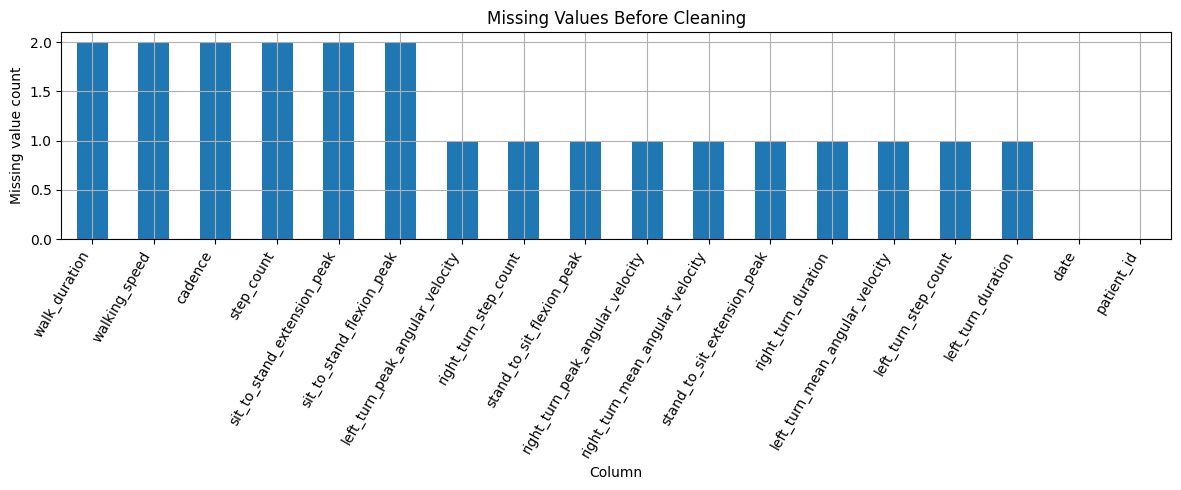

In [8]:
ax = raw_missing.plot(kind="bar")
ax.set_title("Missing Values Before Cleaning")
ax.set_ylabel("Missing value count")
ax.set_xlabel("Column")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 9. Plot Example Patients Before Cleaning

Plot a few selected features over time for one or two example patients. This helps visually inspect gaps and unusual patterns before cleaning.

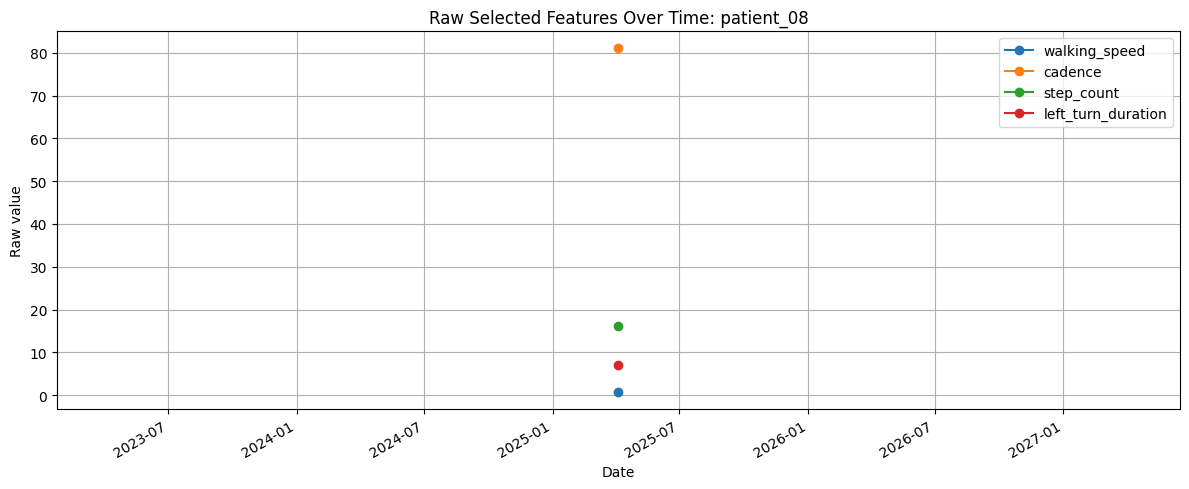

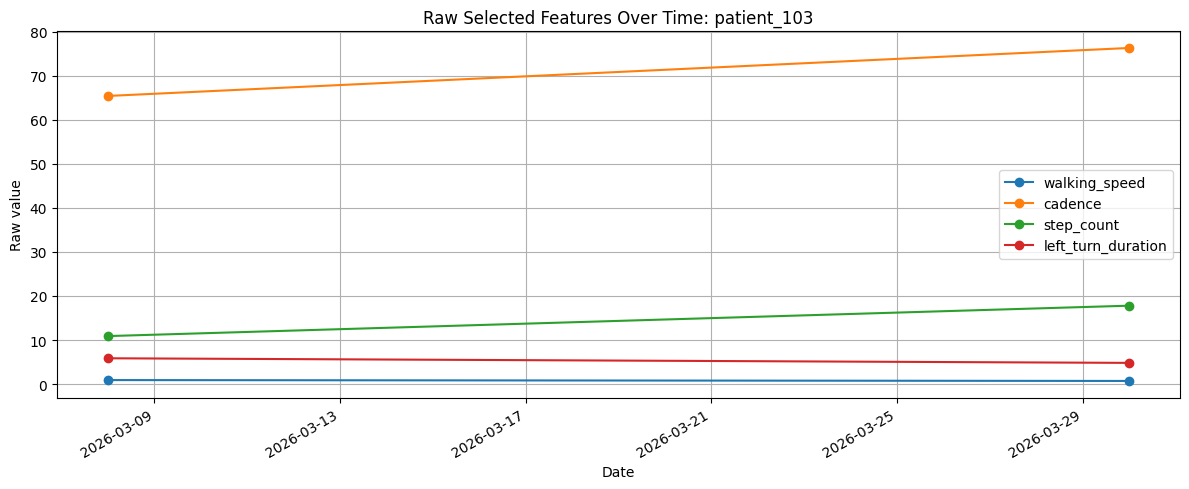

In [9]:
def extract_date(value):
    """Extract a YYYY-MM-DD date from values like D10_2025-12-16."""
    if pd.isna(value):
        return pd.NaT
    text = str(value)
    match = re.search(r"\d{4}-\d{2}-\d{2}", text)
    if match:
        return pd.to_datetime(match.group(0), errors="coerce")
    return pd.to_datetime(text, errors="coerce")

preview_df = raw_df.copy()
preview_df["parsed_date"] = preview_df["date"].apply(extract_date)

example_features = ["walking_speed", "cadence", "step_count", "left_turn_duration"]
example_features = [col for col in example_features if col in preview_df.columns]

valid_preview_patients = (
    preview_df.loc[preview_df["patient_id"].notna() & (preview_df["patient_id"] != "_screenshots"), "patient_id"]
    .drop_duplicates()
    .head(2)
    .tolist()
)

for patient_id in valid_preview_patients:
    patient_data = preview_df[preview_df["patient_id"] == patient_id].sort_values("parsed_date")
    if patient_data.empty:
        continue

    ax = patient_data.plot(x="parsed_date", y=example_features, marker="o")
    ax.set_title(f"Raw Selected Features Over Time: {patient_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Raw value")
    plt.tight_layout()
    plt.show()

if not valid_preview_patients:
    print("No valid patients found for preview plotting.")

## 10. Clean the Data

Clean the raw dataframe by removing unusable patient/date rows, removing `_screenshots`, parsing dates, sorting by patient and date, and keeping only the selected columns.

In [10]:
clean_df = raw_df.copy()

clean_df = clean_df[clean_df["patient_id"].notna()].copy()
clean_df = clean_df[clean_df["date"].notna()].copy()
clean_df = clean_df[clean_df["patient_id"] != "_screenshots"].copy()

clean_df["date"] = clean_df["date"].apply(extract_date)
clean_df = clean_df[clean_df["date"].notna()].copy()

clean_df = clean_df[KEEP_COLUMNS].copy()

# Convert selected feature columns to numeric values.
# Non-numeric values become NaN so they can be handled consistently.
for col in FEATURE_COLUMNS:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

clean_df = clean_df.sort_values(["patient_id", "date"]).reset_index(drop=True)

print(f"Cleaned dataframe shape before filling: {clean_df.shape}")
clean_df.head()

Cleaned dataframe shape before filling: (8, 18)


,patient_id,date,walk_duration,walking_speed,cadence,step_count,left_turn_duration,left_turn_step_count,left_turn_mean_angular_velocity,left_turn_peak_angular_velocity,right_turn_duration,right_turn_step_count,right_turn_mean_angular_velocity,right_turn_peak_angular_velocity,sit_to_stand_flexion_peak,sit_to_stand_extension_peak,stand_to_sit_flexion_peak,stand_to_sit_extension_peak
0,patient_08,2025-04-05,11.9,0.840,81.000,16.20,6.944,18.0,0.698,1.504,5.194,17.0,1.003,2.101,1.752,-1.718,1.748,-2.541
1,patient_103,2026-03-08,10.9,0.917,65.400,10.90,5.864,7.0,1.111,2.307,5.214,7.0,1.090,2.176,1.843,-1.944,1.110,-1.172
2,patient_103,2026-03-30,13.9,0.719,76.286,17.80,4.821,5.0,1.152,2.189,4.811,5.0,0.975,2.082,NaN,NaN,NaN,NaN
3,patient_111,2026-04-28,26.9,0.372,84.188,22.45,4.573,5.0,1.382,2.450,5.914,9.0,0.998,1.583,1.102,-0.799,1.739,-1.164
4,patient_111,2026-04-29,15.9,0.629,103.875,27.70,4.020,5.0,1.482,2.446,4.503,6.0,1.186,2.007,0.735,-3.965,0.681,-3.994


## 11. Missing Values Before Filling

Save missing value counts before filling so we can compare them against the counts after patient-wise filling.

In [11]:
missing_before_fill = clean_df[FEATURE_COLUMNS].isna().sum().sort_values(ascending=False)
missing_before_fill

sit_to_stand_flexion_peak           2
sit_to_stand_extension_peak         2
left_turn_duration                  1
left_turn_step_count                1
left_turn_mean_angular_velocity     1
left_turn_peak_angular_velocity     1
right_turn_duration                 1
right_turn_step_count               1
right_turn_mean_angular_velocity    1
right_turn_peak_angular_velocity    1
stand_to_sit_flexion_peak           1
stand_to_sit_extension_peak         1
walk_duration                       0
walking_speed                       0
cadence                             0
step_count                          0
dtype: int64

## 12. Fill Missing Values Patient-wise

For each patient separately, use forward fill and backward fill. This fills gaps within a patient without copying values from another patient.

In [12]:
filled_df = clean_df.copy()
filled_df[FEATURE_COLUMNS] = (
    filled_df
    .groupby("patient_id", group_keys=False)[FEATURE_COLUMNS]
    .apply(lambda group: group.ffill().bfill())
)

missing_after_fill = filled_df[FEATURE_COLUMNS].isna().sum().sort_values(ascending=False)
print(f"Filled dataframe shape: {filled_df.shape}")
filled_df.head()

Filled dataframe shape: (8, 18)


,patient_id,date,walk_duration,walking_speed,cadence,step_count,left_turn_duration,left_turn_step_count,left_turn_mean_angular_velocity,left_turn_peak_angular_velocity,right_turn_duration,right_turn_step_count,right_turn_mean_angular_velocity,right_turn_peak_angular_velocity,sit_to_stand_flexion_peak,sit_to_stand_extension_peak,stand_to_sit_flexion_peak,stand_to_sit_extension_peak
0,patient_08,2025-04-05,11.9,0.840,81.000,16.20,6.944,18.0,0.698,1.504,5.194,17.0,1.003,2.101,1.752,-1.718,1.748,-2.541
1,patient_103,2026-03-08,10.9,0.917,65.400,10.90,5.864,7.0,1.111,2.307,5.214,7.0,1.090,2.176,1.843,-1.944,1.110,-1.172
2,patient_103,2026-03-30,13.9,0.719,76.286,17.80,4.821,5.0,1.152,2.189,4.811,5.0,0.975,2.082,1.843,-1.944,1.110,-1.172
3,patient_111,2026-04-28,26.9,0.372,84.188,22.45,4.573,5.0,1.382,2.450,5.914,9.0,0.998,1.583,1.102,-0.799,1.739,-1.164
4,patient_111,2026-04-29,15.9,0.629,103.875,27.70,4.020,5.0,1.482,2.446,4.503,6.0,1.186,2.007,0.735,-3.965,0.681,-3.994


## 13. Missing Counts Before and After Filling

Compare missing value counts before and after filling using a table and bar plot.

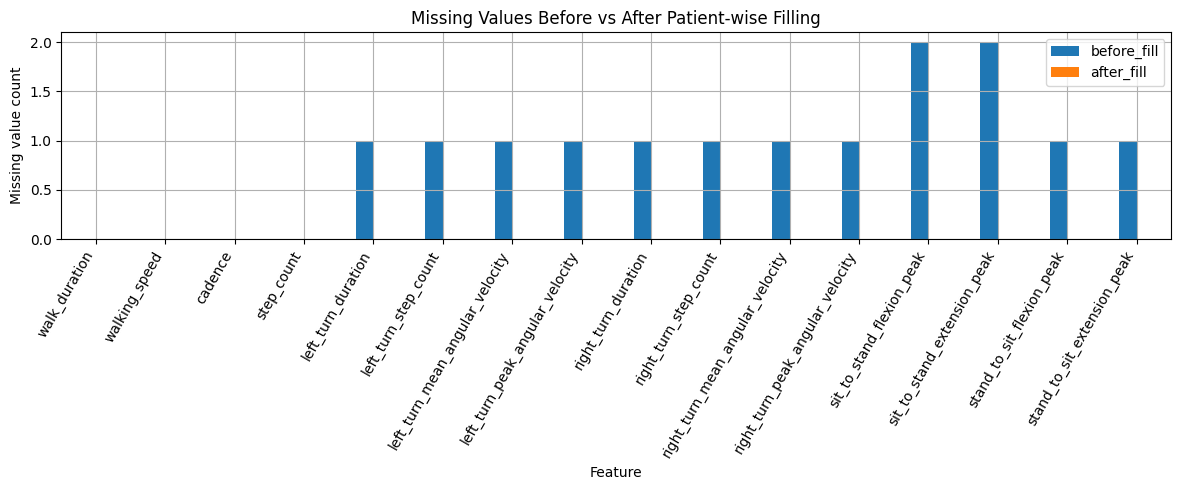

,before_fill,after_fill
walk_duration,0,0
walking_speed,0,0
cadence,0,0
step_count,0,0
left_turn_duration,1,0
left_turn_step_count,1,0
left_turn_mean_angular_velocity,1,0
left_turn_peak_angular_velocity,1,0
right_turn_duration,1,0
right_turn_step_count,1,0


In [13]:
missing_compare = pd.DataFrame({
    "before_fill": missing_before_fill,
    "after_fill": missing_after_fill,
}).loc[FEATURE_COLUMNS]

ax = missing_compare.plot(kind="bar")
ax.set_title("Missing Values Before vs After Patient-wise Filling")
ax.set_ylabel("Missing value count")
ax.set_xlabel("Feature")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

missing_compare

## 14. Visual Check Before and After Filling

For one sample patient, compare selected features before and after filling. The filled version should have fewer gaps when nearby values exist.

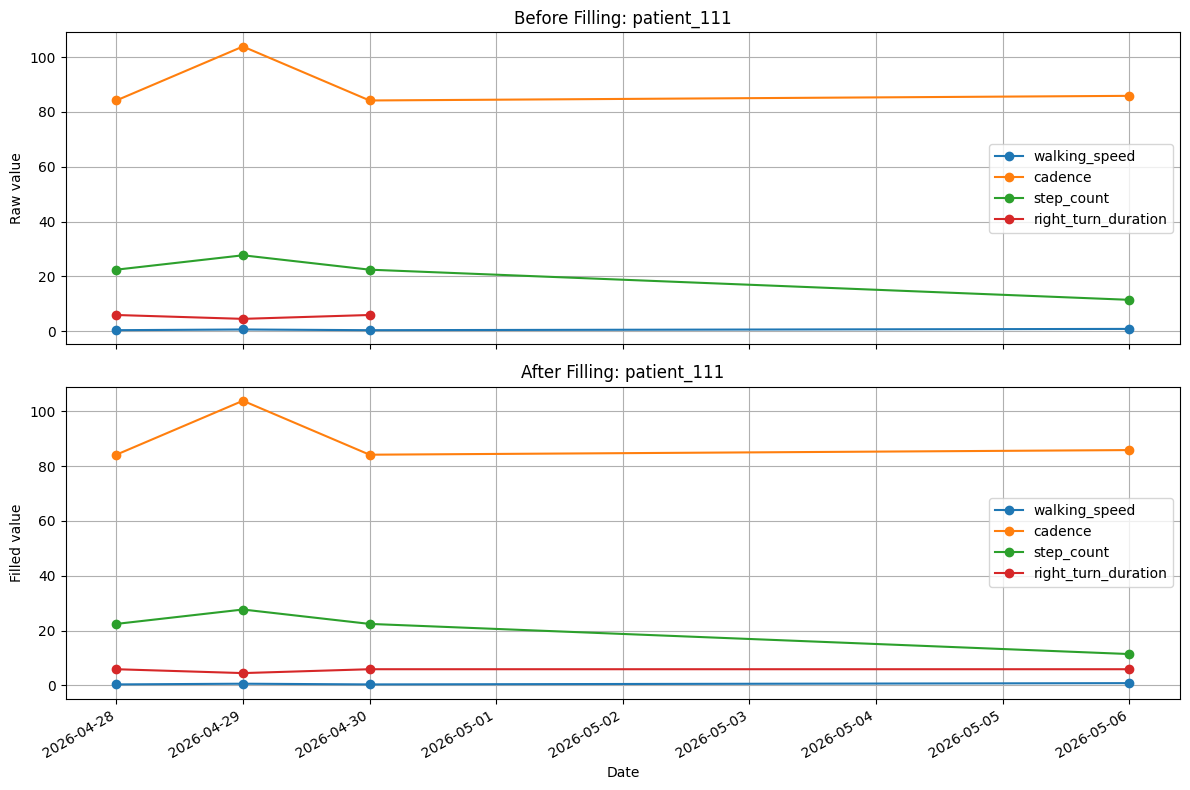

In [14]:
def choose_patient_with_data(df, min_rows=2):
    counts = df.groupby("patient_id").size().sort_values(ascending=False)
    counts = counts[counts >= min_rows]
    if counts.empty:
        return None
    return counts.index[0]

sample_patient = choose_patient_with_data(clean_df)
plot_features = ["walking_speed", "cadence", "step_count", "right_turn_duration"]
plot_features = [col for col in plot_features if col in FEATURE_COLUMNS]

if sample_patient is None:
    print("No patient available for before/after filling plot.")
else:
    before_patient = clean_df[clean_df["patient_id"] == sample_patient].sort_values("date")
    after_patient = filled_df[filled_df["patient_id"] == sample_patient].sort_values("date")

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    before_patient.plot(x="date", y=plot_features, marker="o", ax=axes[0])
    axes[0].set_title(f"Before Filling: {sample_patient}")
    axes[0].set_ylabel("Raw value")

    after_patient.plot(x="date", y=plot_features, marker="o", ax=axes[1])
    axes[1].set_title(f"After Filling: {sample_patient}")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Filled value")

    plt.tight_layout()
    plt.show()

## 15. Drop Unusable Data

Drop rows that are still fully empty across the selected features. Then keep only patients with at least 8 usable rows.

In [15]:
non_empty_rows = ~filled_df[FEATURE_COLUMNS].isna().all(axis=1)
usable_df = filled_df[non_empty_rows].copy()

usable_row_counts = usable_df.groupby("patient_id").size()
usable_patient_ids = usable_row_counts[usable_row_counts >= INPUT_DAYS + TARGET_DAYS].index.tolist()

usable_df = usable_df[usable_df["patient_id"].isin(usable_patient_ids)].copy()
usable_df = usable_df.sort_values(["patient_id", "date"]).reset_index(drop=True)

print(f"Rows after dropping unusable data: {len(usable_df)}")
print(f"Usable patients with at least {INPUT_DAYS + TARGET_DAYS} rows: {len(usable_patient_ids)}")
usable_df.head()

Rows after dropping unusable data: 0
Usable patients with at least 8 rows: 0


,patient_id,date,walk_duration,walking_speed,cadence,step_count,left_turn_duration,left_turn_step_count,left_turn_mean_angular_velocity,left_turn_peak_angular_velocity,right_turn_duration,right_turn_step_count,right_turn_mean_angular_velocity,right_turn_peak_angular_velocity,sit_to_stand_flexion_peak,sit_to_stand_extension_peak,stand_to_sit_flexion_peak,stand_to_sit_extension_peak


## 16. Summary Statistics Before Normalization

Inspect feature summary statistics before normalization so you can compare them with the normalized version later.

In [16]:
stats_before_norm = usable_df[FEATURE_COLUMNS].describe().T
stats_before_norm

,count,mean,std,min,25%,50%,75%,max
walk_duration,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
walking_speed,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cadence,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
step_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
left_turn_duration,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
left_turn_step_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
left_turn_mean_angular_velocity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
left_turn_peak_angular_velocity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
right_turn_duration,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
right_turn_step_count,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 17. Normalize Features Patient-wise

Normalize each feature separately within each patient using z-score normalization: `(x - mean) / std`. If standard deviation is 0 or missing, use 1.0 to avoid division by zero.

In [17]:
normalized_parts = []

for patient_id, patient_data in usable_df.groupby("patient_id", sort=False):
    patient_norm = patient_data.copy()

    means = patient_norm[FEATURE_COLUMNS].mean()
    stds = patient_norm[FEATURE_COLUMNS].std()
    stds = stds.replace(0, 1.0).fillna(1.0)

    patient_norm[FEATURE_COLUMNS] = (patient_norm[FEATURE_COLUMNS] - means) / stds
    normalized_parts.append(patient_norm)

if normalized_parts:
    normalized_df = pd.concat(normalized_parts, ignore_index=True)
else:
    normalized_df = usable_df.copy()

normalized_df = normalized_df.sort_values(["patient_id", "date"]).reset_index(drop=True)

if "patient_id" not in normalized_df.columns:
    raise KeyError("patient_id column is missing after normalization.")


stats_after_norm = normalized_df[FEATURE_COLUMNS].describe().T
print(f"Normalized dataframe shape: {normalized_df.shape}")
normalized_df.head()

Normalized dataframe shape: (0, 18)


,patient_id,date,walk_duration,walking_speed,cadence,step_count,left_turn_duration,left_turn_step_count,left_turn_mean_angular_velocity,left_turn_peak_angular_velocity,right_turn_duration,right_turn_step_count,right_turn_mean_angular_velocity,right_turn_peak_angular_velocity,sit_to_stand_flexion_peak,sit_to_stand_extension_peak,stand_to_sit_flexion_peak,stand_to_sit_extension_peak


## 18. Summary Statistics Before and After Normalization

Compare feature means and standard deviations before and after normalization.

In [18]:
summary_compare = pd.DataFrame({
    "before_mean": stats_before_norm["mean"],
    "before_std": stats_before_norm["std"],
    "after_mean": stats_after_norm["mean"],
    "after_std": stats_after_norm["std"],
})
summary_compare

,before_mean,before_std,after_mean,after_std
walk_duration,NaN,NaN,NaN,NaN
walking_speed,NaN,NaN,NaN,NaN
cadence,NaN,NaN,NaN,NaN
step_count,NaN,NaN,NaN,NaN
left_turn_duration,NaN,NaN,NaN,NaN
left_turn_step_count,NaN,NaN,NaN,NaN
left_turn_mean_angular_velocity,NaN,NaN,NaN,NaN
left_turn_peak_angular_velocity,NaN,NaN,NaN,NaN
right_turn_duration,NaN,NaN,NaN,NaN
right_turn_step_count,NaN,NaN,NaN,NaN


## 19. Plot Normalized Features

Plot a few normalized features for one patient. Values are now shown relative to that patient's own baseline.

In [19]:
norm_sample_patient = choose_patient_with_data(normalized_df, min_rows=INPUT_DAYS + TARGET_DAYS)
normalized_plot_features = ["walking_speed", "cadence", "step_count", "left_turn_duration"]
normalized_plot_features = [col for col in normalized_plot_features if col in FEATURE_COLUMNS]

if norm_sample_patient is None:
    print("No usable patient available for normalized plot.")
else:
    norm_patient = normalized_df[normalized_df["patient_id"] == norm_sample_patient].sort_values("date")
    ax = norm_patient.plot(x="date", y=normalized_plot_features, marker="o")
    ax.set_title(f"Normalized Features Over Time: {norm_sample_patient}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Patient-wise z-score")
    plt.tight_layout()
    plt.show()

No usable patient available for normalized plot.


## 20. Build Sliding Windows

Build LSTM samples where `X` contains the previous 7 days and `y` contains the next day. The final shapes are `(num_samples, 7, num_features)` for `X` and `(num_samples, num_features)` for `y`.

In [20]:
def build_sliding_windows(df, feature_columns, input_days=7):
    X_list = []
    y_list = []
    patient_list = []
    target_date_list = []

    for patient_id, patient_data in df.groupby("patient_id"):
        patient_data = patient_data.sort_values("date").reset_index(drop=True)
        values = patient_data[feature_columns].to_numpy(dtype=np.float32)
        dates = patient_data["date"].to_numpy()

        if len(patient_data) < input_days + 1:
            continue

        for start_idx in range(0, len(patient_data) - input_days):
            end_idx = start_idx + input_days
            X_list.append(values[start_idx:end_idx])
            y_list.append(values[end_idx])
            patient_list.append(patient_id)
            target_date_list.append(dates[end_idx])

    if not X_list:
        X = np.empty((0, input_days, len(feature_columns)), dtype=np.float32)
        y = np.empty((0, len(feature_columns)), dtype=np.float32)
    else:
        X = np.stack(X_list).astype(np.float32)
        y = np.stack(y_list).astype(np.float32)

    metadata = pd.DataFrame({
        "patient_id": patient_list,
        "target_date": target_date_list,
    })

    return X, y, metadata

X_all, y_all, window_metadata = build_sliding_windows(normalized_df, FEATURE_COLUMNS, INPUT_DAYS)

print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
window_metadata.head()

X_all shape: (0, 7, 16)
y_all shape: (0, 16)


,patient_id,target_date


## 21. Split Train, Validation, and Test by Patient

Split by `patient_id`, not by rows. This keeps all windows from one patient in only one split and gives a more honest evaluation.

In [21]:
def split_patient_ids(patient_ids, random_state=42):
    # Convert to a pandas Index first so this works across pandas versions.
    patient_ids = np.array(sorted(pd.Index(patient_ids).dropna().unique()))
    n_patients = len(patient_ids)

    if n_patients == 0:
        return np.array([]), np.array([]), np.array([])
    if n_patients == 1:
        return patient_ids, np.array([]), np.array([])
    if n_patients == 2:
        train_ids, test_ids = train_test_split(patient_ids, test_size=1, random_state=random_state)
        return np.array(train_ids), np.array([]), np.array(test_ids)

    # For 3 or more patients, reserve at least one patient for test.
    test_size = max(1, int(round(n_patients * 0.20)))
    train_val_ids, test_ids = train_test_split(patient_ids, test_size=test_size, random_state=random_state)

    if len(train_val_ids) == 1:
        return np.array(train_val_ids), np.array([]), np.array(test_ids)

    # Reserve at least one patient for validation from the remaining patients.
    val_size = max(1, int(round(len(train_val_ids) * 0.20)))
    if val_size >= len(train_val_ids):
        val_size = 1

    train_ids, val_ids = train_test_split(train_val_ids, test_size=val_size, random_state=random_state)
    return np.array(train_ids), np.array(val_ids), np.array(test_ids)

all_window_patient_ids = window_metadata["patient_id"].unique() if len(window_metadata) else []
train_patient_ids, val_patient_ids, test_patient_ids = split_patient_ids(all_window_patient_ids, RANDOM_STATE)

train_mask = window_metadata["patient_id"].isin(train_patient_ids).to_numpy() if len(window_metadata) else np.array([], dtype=bool)
val_mask = window_metadata["patient_id"].isin(val_patient_ids).to_numpy() if len(window_metadata) else np.array([], dtype=bool)
test_mask = window_metadata["patient_id"].isin(test_patient_ids).to_numpy() if len(window_metadata) else np.array([], dtype=bool)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Total number of unique patients in raw data: {raw_df['patient_id'].nunique(dropna=True)}")
print(f"Number of usable patients: {len(usable_patient_ids)}")
print(f"Number of rows after cleaning: {len(normalized_df)}")
print()
print(f"Train patient count: {len(train_patient_ids)}")
print(f"Validation patient count: {len(val_patient_ids)}")
print(f"Test patient count: {len(test_patient_ids)}")
print()
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

Total number of unique patients in raw data: 4
Number of usable patients: 0
Number of rows after cleaning: 0

Train patient count: 0
Validation patient count: 0
Test patient count: 0

X_train shape: (0, 7, 16)
y_train shape: (0, 16)
X_val shape:   (0, 7, 16)
y_val shape:   (0, 16)
X_test shape:  (0, 7, 16)
y_test shape:  (0, 16)


## 22. Save Cleaned Data and NumPy Arrays

Save the cleaned normalized feature table and the train, validation, and test arrays.

In [22]:
cleaned_csv_path = OUTPUT_DIR / "cleaned_lstm_features.csv"
normalized_df.to_csv(cleaned_csv_path, index=False)

np.save(OUTPUT_DIR / "X_train.npy", X_train)
np.save(OUTPUT_DIR / "y_train.npy", y_train)
np.save(OUTPUT_DIR / "X_val.npy", X_val)
np.save(OUTPUT_DIR / "y_val.npy", y_val)
np.save(OUTPUT_DIR / "X_test.npy", X_test)
np.save(OUTPUT_DIR / "y_test.npy", y_test)

print("Saved files:")
for filename in [
    "cleaned_lstm_features.csv",
    "X_train.npy", "y_train.npy",
    "X_val.npy", "y_val.npy",
    "X_test.npy", "y_test.npy",
]:
    path = OUTPUT_DIR / filename
    print(f"- {path} ({path.stat().st_size:,} bytes)")

Saved files:
- cleaned_lstm_features.csv (383 bytes)
- X_train.npy (128 bytes)
- y_train.npy (128 bytes)
- X_val.npy (128 bytes)
- y_val.npy (128 bytes)
- X_test.npy (128 bytes)
- y_test.npy (128 bytes)


## 23. Baseline Model: Last Day Equals Next Day

Use a simple baseline where the prediction for the next day is equal to the last day in the input window. This gives the LSTM something to beat.

In [23]:
if len(X_test) == 0:
    print("No test samples are available, so baseline MAE cannot be computed.")
else:
    baseline_pred = X_test[:, -1, :]
    baseline_abs_error = np.abs(baseline_pred - y_test)
    baseline_overall_mae = baseline_abs_error.mean()
    baseline_per_feature_mae = baseline_abs_error.mean(axis=0)

    print(f"Overall baseline MAE: {baseline_overall_mae:.4f}")
    print("\nPer-feature baseline MAE:")
    baseline_mae_df = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "baseline_mae": baseline_per_feature_mae,
    })
    display(baseline_mae_df)

No test samples are available, so baseline MAE cannot be computed.


## 24. Simple LSTM Model

Train a small LSTM with one 64-unit LSTM layer and one Dense output layer. If TensorFlow is not installed, this cell prints a message instead of stopping the whole notebook.

In [24]:
model = None
history = None
lstm_test_mae = None

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    tf.random.set_seed(RANDOM_STATE)

    if len(X_train) == 0:
        print("No training samples are available, so the LSTM cannot be trained.")
    else:
        model = keras.Sequential([
            layers.Input(shape=(INPUT_DAYS, NUM_FEATURES)),
            layers.LSTM(64),
            layers.Dense(NUM_FEATURES),
        ])

        model.compile(
            optimizer=keras.optimizers.Adam(),
            loss="mae",
            metrics=["mae"],
        )

        model.summary()

        fit_kwargs = {
            "x": X_train,
            "y": y_train,
            "epochs": 50,
            "batch_size": min(32, max(1, len(X_train))),
            "verbose": 1,
        }

        if len(X_val) > 0:
            fit_kwargs["validation_data"] = (X_val, y_val)
        elif len(X_train) >= 5:
            fit_kwargs["validation_split"] = 0.2
        else:
            print("Very small training set: training without validation data.")

        history = model.fit(**fit_kwargs)

        if len(X_test) > 0:
            eval_results = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
            lstm_test_mae = eval_results.get("mae", eval_results.get("loss"))
            print(f"Overall LSTM test MAE: {lstm_test_mae:.4f}")
        else:
            print("No test samples are available, so LSTM test MAE cannot be computed.")

except ImportError as exc:
    print("TensorFlow/Keras is not installed in this environment.")
    print("Install TensorFlow to run the LSTM section.")
    print(exc)

No training samples are available, so the LSTM cannot be trained.


## 25. Plot Training and Validation Loss

Plot the training curve so you can see whether loss decreases and how validation loss compares to training loss.

In [25]:
if history is None:
    print("No training history available to plot.")
else:
    history_df = pd.DataFrame(history.history)

    ax = history_df[[col for col in ["loss", "val_loss"] if col in history_df.columns]].plot()
    ax.set_title("LSTM Training Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE loss")
    plt.tight_layout()
    plt.show()

    history_df.tail()

No training history available to plot.


## 26. Visualize One Prediction

Choose one test sample and plot the 7 input days plus the true and predicted next-day values for a few selected features.

In [26]:
prediction_plot_features = ["walking_speed", "cadence", "step_count", "left_turn_duration"]
prediction_plot_features = [col for col in prediction_plot_features if col in FEATURE_COLUMNS]
prediction_feature_indices = [FEATURE_COLUMNS.index(col) for col in prediction_plot_features]

if model is None:
    print("No trained LSTM model is available for prediction plotting.")
elif len(X_test) == 0:
    print("No test samples are available for prediction plotting.")
else:
    sample_idx = 0
    sample_X = X_test[sample_idx:sample_idx + 1]
    sample_y_true = y_test[sample_idx]
    sample_y_pred = model.predict(sample_X, verbose=0)[0]

    x_days = np.arange(1, INPUT_DAYS + 2)

    plt.figure(figsize=(12, 6))
    for feature, feature_idx in zip(prediction_plot_features, prediction_feature_indices):
        input_values = sample_X[0, :, feature_idx]
        true_series = np.concatenate([input_values, [sample_y_true[feature_idx]]])
        pred_next_value = sample_y_pred[feature_idx]

        plt.plot(x_days, true_series, marker="o", label=f"{feature} true")
        plt.scatter(INPUT_DAYS + 1, pred_next_value, marker="x", s=120, label=f"{feature} predicted")

    plt.axvline(INPUT_DAYS + 0.5, linestyle="--", color="black", alpha=0.5)
    plt.title("Seven Input Days and True vs Predicted Next Day")
    plt.xlabel("Day in window")
    plt.ylabel("Normalized feature value")
    plt.xticks(x_days, [f"Input {i}" for i in range(1, INPUT_DAYS + 1)] + ["Next day"])
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

No trained LSTM model is available for prediction plotting.


## 27. Final Checklist

At this point, the notebook has:

- Loaded and inspected the raw CSV.
- Cleaned patient/date rows.
- Kept the selected LSTM features.
- Filled missing values within each patient.
- Removed unusable rows and short patient histories.
- Normalized features patient-wise.
- Built 7-day input windows and 1-day targets.
- Split train/validation/test by patient.
- Saved cleaned data and NumPy arrays.
- Computed a last-day baseline.
- Trained and evaluated a simple LSTM when TensorFlow is available.